# project - 1 
# converting raw data into the ml model understandable data

#  basics of data understanding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# data visualization 

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
numeric=['age', 'bmi', 'children', 'charges']

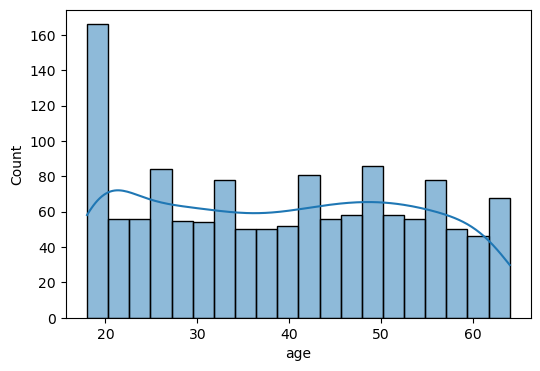

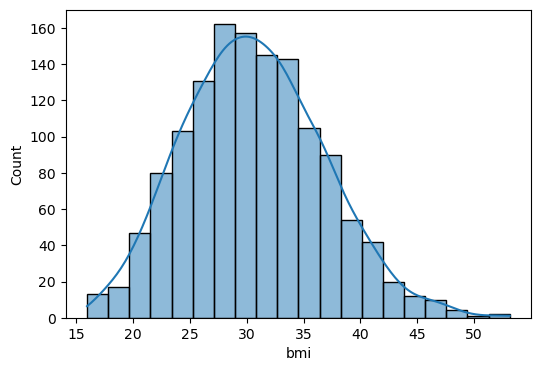

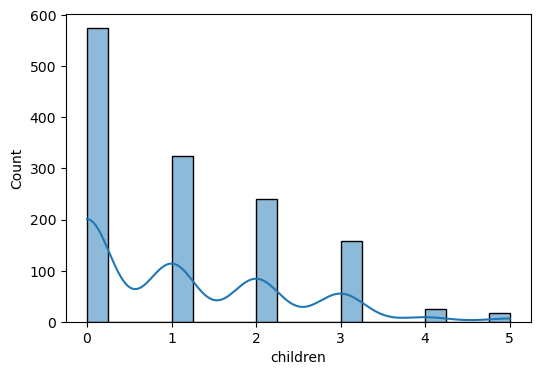

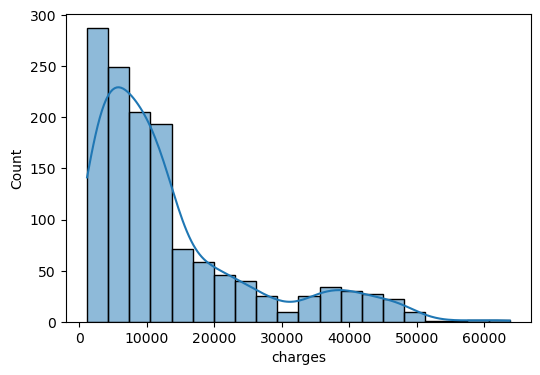

In [10]:
for col in numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)
    plt.show()

<Axes: xlabel='children', ylabel='count'>

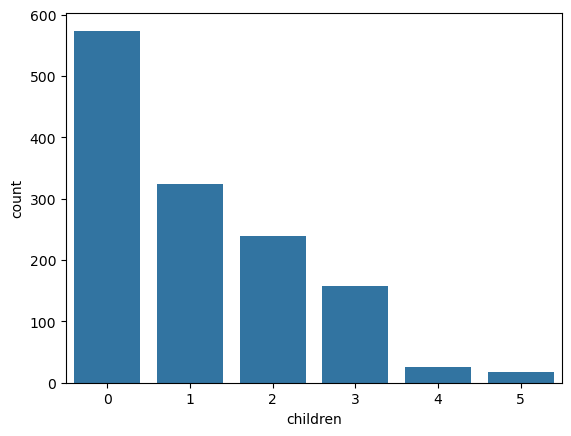

In [11]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

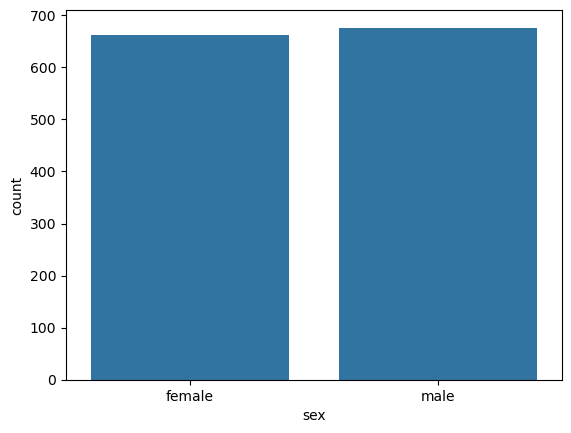

In [12]:
sns.countplot(x='sex',data=df)

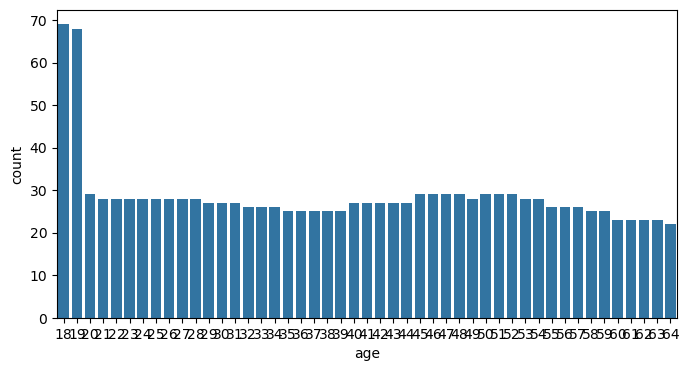

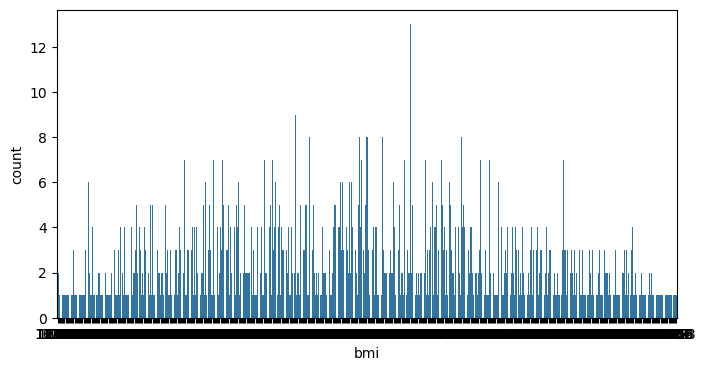

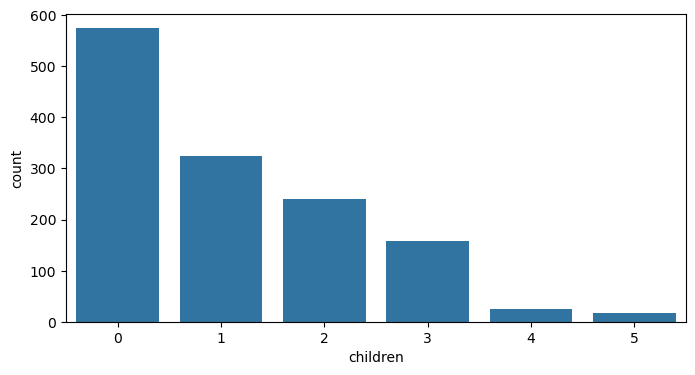

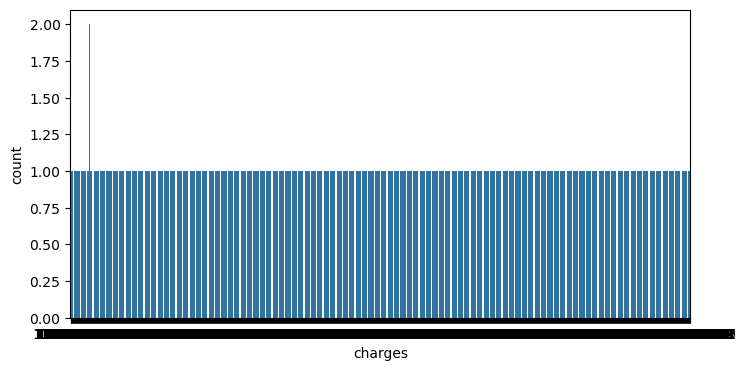

In [13]:
for c in numeric:
    plt.figure(figsize=(8,4))
    sns.countplot(x=c,data=df)
    plt.show()

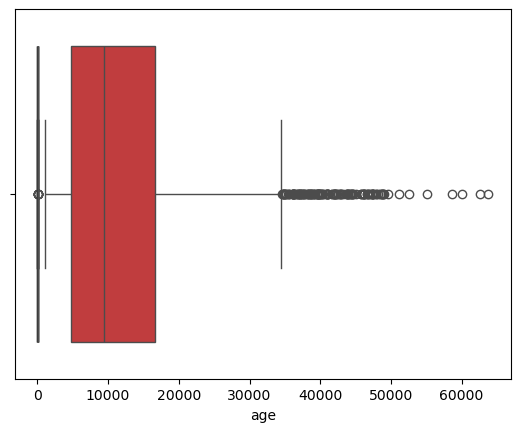

In [14]:
for col in numeric:
    sns.boxplot(data=df,x=col)

# data cleaning 

In [15]:
df_clean=df.copy()

In [16]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [17]:
df_clean.drop_duplicates(inplace=True)

In [18]:
df_clean.shape

(1337, 7)

In [19]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
df_clean.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

# now data preprocesing

In [21]:
# using label encoding to convert the object datatype into int data type
df_clean['sex']=df_clean['sex'].map({ 'male' : 0, 'female' : 1})

In [22]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_clean.rename(columns={ 'sex' : 'isfemale' , 'smoker': 'issmoker' },inplace=True)

In [24]:
df_clean.head()

,age,isfemale,bmi,children,issmoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_clean['issmoker']=df_clean['issmoker'].map({ "yes" : 1 , "no" : 0})

In [26]:
df_clean.head()

,age,isfemale,bmi,children,issmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [27]:
# upto now all columns are converted into the int values excepet one region column only for that now we wounld like to do one hot encoding 
df_clean=pd.get_dummies(df_clean,columns=['region'],drop_first=True)

In [28]:
df_clean.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [29]:
df_clean=df_clean.astype(int)

In [30]:
df_clean.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# feature engineering & extraction 

In [31]:
# for BMI we would like to understand the for that we need to research about bim
#    Underweight: Below 18.5
#    Healthy Weight (Normal): 18.5 to 24.9
#    Overweight: 25.0 to 29.9
#    Obesity: 30.0 or higher

In [32]:
df_clean['bmi']=pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,25.0,30.0,float('inf')],
    labels=['underweight','healthy','overweight','obesity']
)

In [33]:
df_clean.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,overweight,0,1,16884,0,0,1
1,18,0,obesity,1,0,1725,0,1,0
2,28,0,obesity,3,0,4449,0,1,0
3,33,0,healthy,0,0,21984,1,0,0
4,32,0,overweight,0,0,3866,1,0,0


In [34]:
df_clean = pd.get_dummies(df_clean, columns=['bmi'], drop_first=True)

In [35]:
df_clean.head()

,age,isfemale,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_healthy,bmi_overweight,bmi_obesity
0,19,1,0,1,16884,0,0,1,False,True,False
1,18,0,1,0,1725,0,1,0,False,False,True
2,28,0,3,0,4449,0,1,0,False,False,True
3,33,0,0,0,21984,1,0,0,True,False,False
4,32,0,0,0,3866,1,0,0,False,True,False


In [36]:
df_clean=df_clean.astype(int)

In [37]:
df_clean.head()

,age,isfemale,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_healthy,bmi_overweight,bmi_obesity
0,19,1,0,1,16884,0,0,1,0,1,0
1,18,0,1,0,1725,0,1,0,0,0,1
2,28,0,3,0,4449,0,1,0,0,0,1
3,33,0,0,0,21984,1,0,0,1,0,0
4,32,0,0,0,3866,1,0,0,0,1,0


In [38]:
# feature scaling  it means to change into the StandardScaler values
from sklearn.preprocessing import StandardScaler
cols = ['age','children']
scaler = StandardScaler()
df_clean[cols] = scaler.fit_transform(df_clean[cols])


In [39]:
df_clean.head()

,age,isfemale,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_healthy,bmi_overweight,bmi_obesity
0,-1.440418,1,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.909234,0,3866,1,0,0,0,1,0


In [40]:
# now it is ready for the ml model usable csv file formate
#now compare the before comparing and after comparing 
print("before")
print(df.head())
print("after")
print(df_clean.head())

before
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
after
        age  isfemale  children  issmoker  charges  region_northwest  \
0 -1.440418         1 -0.909234         1    16884                 0   
1 -1.511647         0 -0.079442         0     1725                 0   
2 -0.799350         0  1.580143         0     4449                 0   
3 -0.443201         0 -0.909234         0    21984                 1   
4 -0.514431         0 -0.909234         0     3866                 1   

   region_southeast  region_southwest  bmi_healthy  bmi_overweight  \
0                 0                 1            0               1   
1                 1           

# eda completed and now this data can be understand by the ml

# model creation

In [41]:
from sklearn.model_selection import train_test_split

In [43]:
final_df=df_clean

In [44]:
x=final_df.drop('charges',axis=1)
y=final_df['charges']

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

# create a linear model using linear regression

In [47]:
from sklearn.linear_model import LinearRegression

In [51]:
#create a variable for the pridiction model
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
# model evaluation techniques
#performance matrics

In [58]:
# for the R*R 
from sklearn.metrics import r2_score
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
r2

0.8044462184885028

In [59]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7968371219316353

In [60]:
#model prediction percentage is 
prediction_percentage=adjusted_r2*100
print(prediction_percentage)

79.68371219316353


# model creation completed and its accuracy_score is 79.68371219316353